# Experiments for $\texttt{RC-BE}(\alpha)$

## Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import pickle
import os
import hashlib
import matplot2tikz

from agent import *
from instance import *

OUT_FOLDER = 'out'

## Simulations

In [2]:
def run(T, agent, instance, sigma, r, seed):
    agent.reset()
    instance.reset()

    rng = np.random.default_rng(seed=seed)
    cumulative_regret = np.zeros(T + 1)

    for t in trange(1, T + 1, desc=f'Evaluating agent {agent.name}, run #{r+1}'):
        payoffs = instance.next_payoffs()

        arm = agent.pull()
        arm_index = arm - 1

        noise = rng.normal(0, sigma)
        reward = payoffs[arm_index] + noise

        agent.observe(reward)

        best_payoff = max(payoffs)
        instantaneous_regret = best_payoff - payoffs[arm_index]
        cumulative_regret[t] = cumulative_regret[t - 1] + instantaneous_regret

    return cumulative_regret[1:]

In [3]:
def compare_agents(T, agents, instance, sigma, n_runs, seed):
    cumulative_regrets_avg_std_min_max = dict()

    for agent in agents:
        cumulative_regrets = np.zeros((n_runs, T))

        for r in range(n_runs):
            cumulative_regrets[r, :] = run(T, agent, instance, sigma, r, seed+r)

        cumulative_regrets_avg_std_min_max[agent.name] = (np.mean(cumulative_regrets, axis=0), np.std(cumulative_regrets, axis=0),
                                                          np.min(cumulative_regrets, axis=0), np.max(cumulative_regrets, axis=0))

    return (cumulative_regrets_avg_std_min_max, n_runs)

def plot_comparison(plot_name, results, plot_horizon=None, max_points=100, plot_random_agent=False):
    cumulative_regrets_avg_std_min_max = results[0]
    n_runs = results[1]
    agents_names = cumulative_regrets_avg_std_min_max.keys()
    if plot_horizon is None:
        plot_horizon = list(cumulative_regrets_avg_std_min_max.values())[0][0].size

    plt.figure(figsize=(10, 6))

    # Plot each agent's performance
    x_plts = np.linspace(0, plot_horizon, min([plot_horizon, max_points]), endpoint=False, dtype=int)
    for agent_name in agents_names:
        if not plot_random_agent and agent_name == 'Random':
            continue
        plt.plot(x_plts+1, cumulative_regrets_avg_std_min_max[agent_name][0][x_plts], label=agent_name, linewidth=2)
        plt.fill_between(x_plts+1,
                         cumulative_regrets_avg_std_min_max[agent_name][0][x_plts] - 1.96 * cumulative_regrets_avg_std_min_max[agent_name][1][x_plts] / np.sqrt(n_runs),
                         cumulative_regrets_avg_std_min_max[agent_name][0][x_plts] + 1.96 * cumulative_regrets_avg_std_min_max[agent_name][1][x_plts] / np.sqrt(n_runs),
                         alpha=0.2)

    plt.xlabel("Round ($t$)")
    plt.ylabel("Cumulative Regret")
    plt.legend()
    plt.grid(True)

    matplot2tikz.save(f'{OUT_FOLDER}/{plot_name}.tex')

    plt.show()

### Experiment on the exponential instance

Run name: exp-run-0c5a8ab1b40eb87660c12091e49e8cb6a852547b7699695e87995e14eacdf1cb


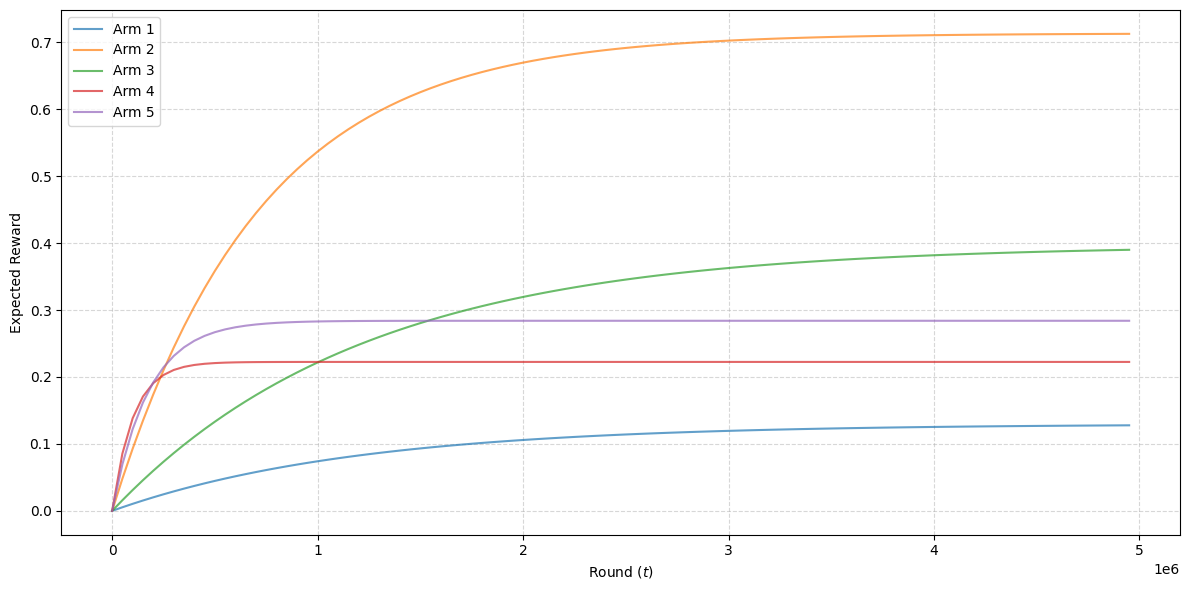

In [4]:
EXP_CONF = {
    'K': 5,
    'T': 5000000,
    'N_RUNS': 10,
    'SIGMA': 0.1,
    'SEED': 9,
    'ALPHA': 8/3,
    'EPSILON': 0.25,
    'ALPHA2': 2.1,
    'SPEED': 50
}

EXP_RUN_NAME = f'exp-run-{hashlib.sha256(str(EXP_CONF).encode()).hexdigest()}'
print(f'Run name: {EXP_RUN_NAME}')

random_agent = RandomAgent(K=EXP_CONF['K'], seed=EXP_CONF['SEED'])
bealpha_agent = RCBEAlphaAgent(K=EXP_CONF['K'], alpha=EXP_CONF['ALPHA'], sigma=EXP_CONF['SIGMA'])
rexpr3_agent = Rexp3Agent(K=EXP_CONF['K'], delta=Rexp3Agent.tune_delta(EXP_CONF['T'], EXP_CONF['K'], EXP_CONF['K']),
                          gamma=Rexp3Agent.tune_gamma(EXP_CONF['T'], EXP_CONF['K'], EXP_CONF['K']),
                          seed=EXP_CONF['SEED'])
rlessucb_agent = RLessUCBAgent(K=EXP_CONF['K'], epsilon=EXP_CONF['EPSILON'], alpha=EXP_CONF['ALPHA2'], sigma=EXP_CONF['SIGMA'])
ucb1_agent = UCB1Agent(K=EXP_CONF['K'], sigma=EXP_CONF['SIGMA'])

agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent, ucb1_agent]

instance = ExponentialInstance(K=EXP_CONF['K'], T=EXP_CONF['T'], seed=EXP_CONF['SEED'], speed=EXP_CONF['SPEED'])

plot_instance('exp-instance', instance, EXP_CONF['T'])

In [5]:
if not os.path.exists(f'{OUT_FOLDER}/{EXP_RUN_NAME}.pkl'):
    results_exp_inst = compare_agents(T=EXP_CONF['T'], agents=agents, instance=instance, sigma=EXP_CONF['SIGMA'], n_runs=EXP_CONF['N_RUNS'], seed=EXP_CONF['SEED'])
    with open(f'{OUT_FOLDER}/{EXP_RUN_NAME}.pkl', 'wb') as f:
        pickle.dump(results_exp_inst, f)

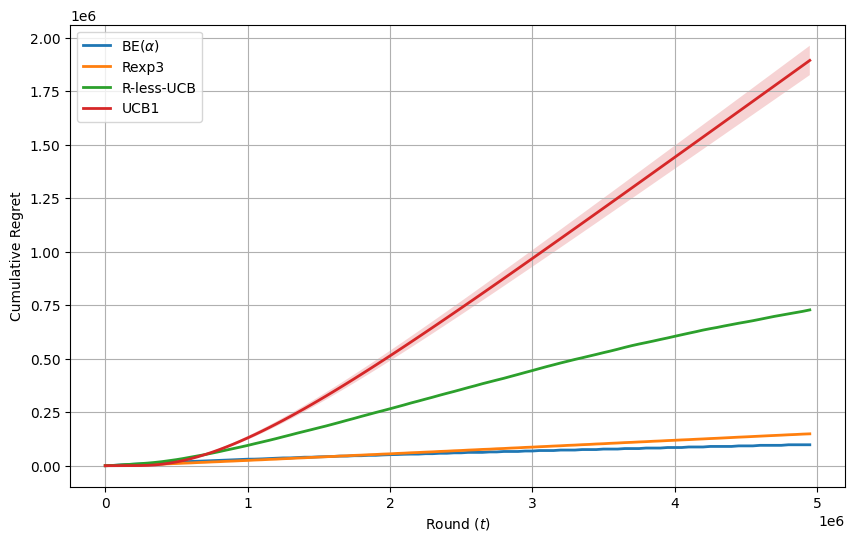

In [6]:
with open(f'{OUT_FOLDER}/{EXP_RUN_NAME}.pkl', 'rb') as f:
    results_exp_inst = pickle.load(f)
plot_comparison('exp-comparison', results_exp_inst)

### Experiment on the piecewise linear instance

Run name: flattened-line-run-2f61f3221ceab256f36faab6653eaa48b21e17e35303d75301b1e424db81cfa6


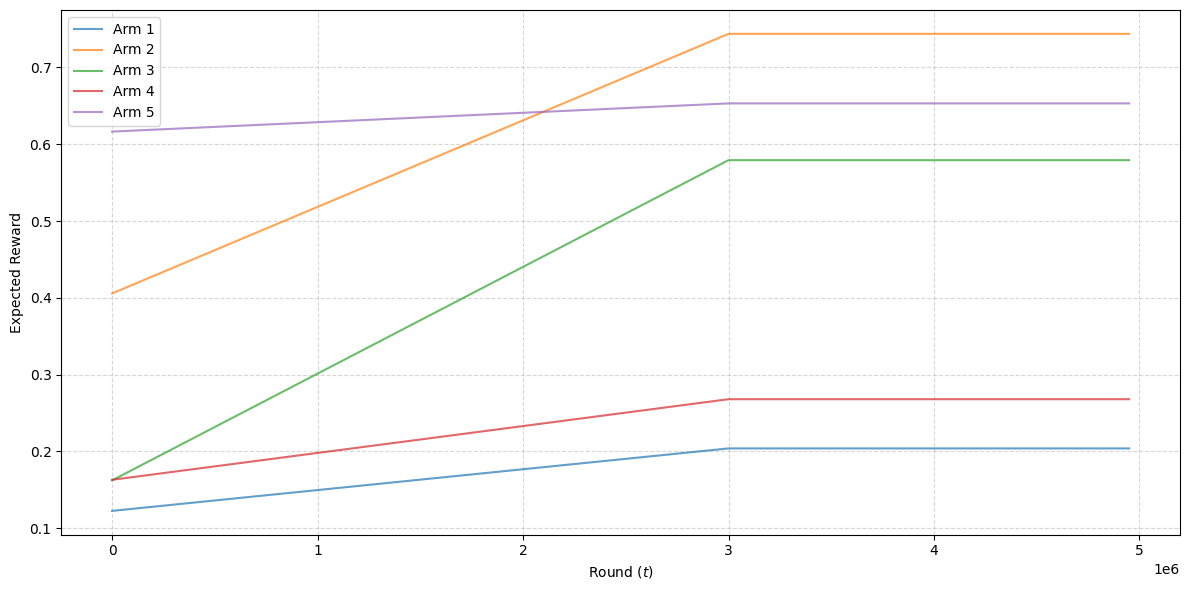

In [7]:
FLATTENED_LINE_CONF = {
    'K': 5,
    'T': 5000000,
    'N_RUNS': 10,
    'SIGMA': 0.1,
    'SEED': 44,
    'ALPHA': 8/3,
    'EPSILON': 0.25,
    'ALPHA2': 2.1,
    'FLATTENING_TIME': 3000000
}

FLATTENED_LINE_RUN_NAME = f'flattened-line-run-{hashlib.sha256(str(FLATTENED_LINE_CONF).encode()).hexdigest()}'
print(f'Run name: {FLATTENED_LINE_RUN_NAME}')

random_agent = RandomAgent(K=FLATTENED_LINE_CONF['K'], seed=FLATTENED_LINE_CONF['SEED'])
bealpha_agent = RCBEAlphaAgent(K=FLATTENED_LINE_CONF['K'], alpha=FLATTENED_LINE_CONF['ALPHA'], sigma=FLATTENED_LINE_CONF['SIGMA'])
rexpr3_agent = Rexp3Agent(K=FLATTENED_LINE_CONF['K'], delta=Rexp3Agent.tune_delta(FLATTENED_LINE_CONF['T'], FLATTENED_LINE_CONF['K'], FLATTENED_LINE_CONF['K']),
                          gamma=Rexp3Agent.tune_gamma(FLATTENED_LINE_CONF['T'], FLATTENED_LINE_CONF['K'], FLATTENED_LINE_CONF['K']),
                          seed=FLATTENED_LINE_CONF['SEED'])
rlessucb_agent = RLessUCBAgent(K=FLATTENED_LINE_CONF['K'], epsilon=FLATTENED_LINE_CONF['EPSILON'], alpha=FLATTENED_LINE_CONF['ALPHA2'], sigma=FLATTENED_LINE_CONF['SIGMA'])
ucb1_agent = UCB1Agent(K=FLATTENED_LINE_CONF['K'], sigma=FLATTENED_LINE_CONF['SIGMA'])

agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent, ucb1_agent]

instance = FlattenedInstance(K=FLATTENED_LINE_CONF['K'], instance=LineInstance(K=FLATTENED_LINE_CONF['K'], T=FLATTENED_LINE_CONF['T'], seed=FLATTENED_LINE_CONF['SEED']),
                             flattening_time=FLATTENED_LINE_CONF['FLATTENING_TIME'])
plot_instance('flattened-line-instance', instance, FLATTENED_LINE_CONF['T'])

In [8]:
if not os.path.exists(f'{OUT_FOLDER}/{FLATTENED_LINE_RUN_NAME}.pkl'):
    results_line_inst = compare_agents(T=FLATTENED_LINE_CONF['T'], agents=agents, instance=instance, sigma=FLATTENED_LINE_CONF['SIGMA'], n_runs=FLATTENED_LINE_CONF['N_RUNS'], seed=FLATTENED_LINE_CONF['SEED'])
    with open(f'{OUT_FOLDER}/{FLATTENED_LINE_RUN_NAME}.pkl', 'wb') as f:
        pickle.dump(results_line_inst, f)

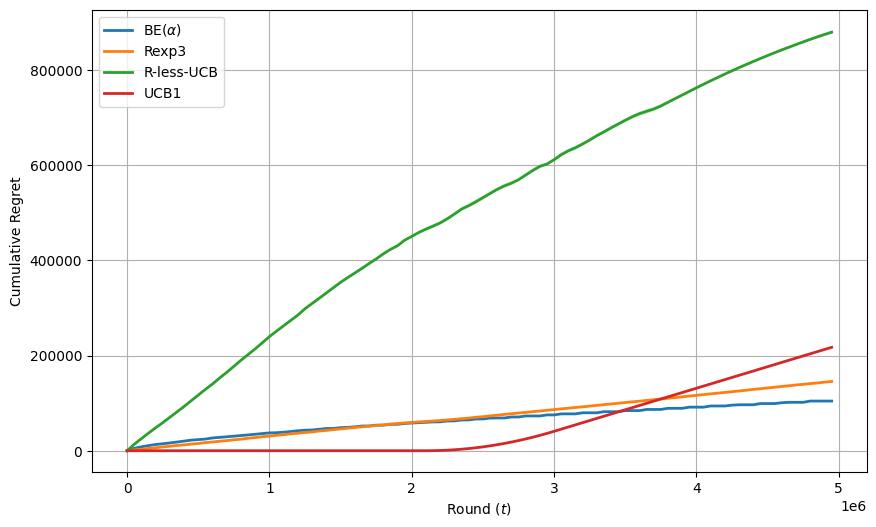

In [9]:
with open(f'{OUT_FOLDER}/{FLATTENED_LINE_RUN_NAME}.pkl', 'rb') as f:
    results_line_inst = pickle.load(f)
plot_comparison('flattened-line-comparison', results_line_inst)

### Experiment on the stationary instance

Stationary run name: stat-run-75df7b604dcd796eb773502a11e4327d6ffd23e90a08a394e0fab331acd3d012


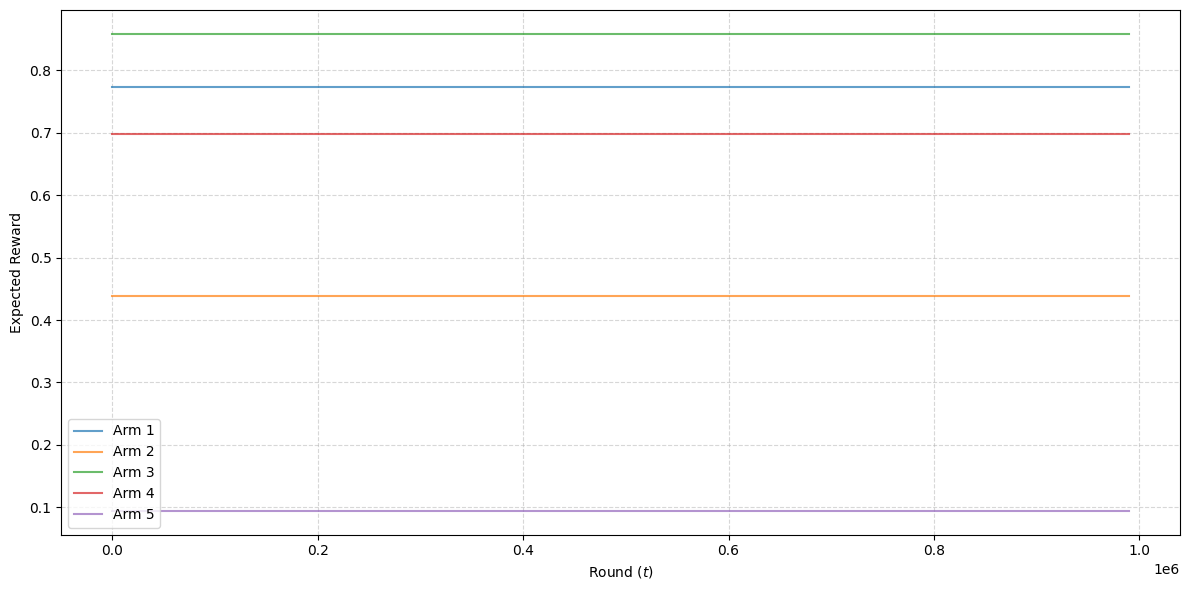

In [10]:
STAT_CONF = {
    'K': 5,
    'T': 1000000,
    'N_RUNS': 10,
    'SIGMA': 0.01,
    'SEED': 42,
    'ALPHA': 8/3,
    'EPSILON': 0.25,
    'ALPHA2': 2.1
}

STAT_RUN_NAME = f'stat-run-{hashlib.sha256(str(STAT_CONF).encode()).hexdigest()}'
print(f'Stationary run name: {STAT_RUN_NAME}')

random_agent = RandomAgent(K=STAT_CONF['K'], seed=STAT_CONF['SEED'])
bealpha_agent = RCBEAlphaAgent(K=STAT_CONF['K'], alpha=STAT_CONF['ALPHA'], sigma=STAT_CONF['SIGMA'])
rexpr3_agent = Rexp3Agent(K=STAT_CONF['K'], delta=Rexp3Agent.tune_delta(STAT_CONF['T'], STAT_CONF['K'], STAT_CONF['K']),
                          gamma=Rexp3Agent.tune_gamma(STAT_CONF['T'], STAT_CONF['K'], STAT_CONF['K']),
                          seed=STAT_CONF['SEED'])
rlessucb_agent = RLessUCBAgent(K=STAT_CONF['K'], epsilon=STAT_CONF['EPSILON'], alpha=STAT_CONF['ALPHA2'], sigma=STAT_CONF['SIGMA'])
ucb1_agent = UCB1Agent(K=STAT_CONF['K'], sigma=STAT_CONF['SIGMA'])

agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent, ucb1_agent]

instance = StationaryInstance(K=STAT_CONF['K'], seed=STAT_CONF['SEED'])
plot_instance('stat-instance', instance, STAT_CONF['T'])

In [11]:
if not os.path.exists(f'{OUT_FOLDER}/{STAT_RUN_NAME}.pkl'):
    results_stat_inst = compare_agents(T=STAT_CONF['T'], agents=agents, instance=instance, sigma=STAT_CONF['SIGMA'], n_runs=STAT_CONF['N_RUNS'], seed=STAT_CONF['SEED'])
    with open(f'{OUT_FOLDER}/{STAT_RUN_NAME}.pkl', 'wb') as f:
        pickle.dump(results_stat_inst, f)

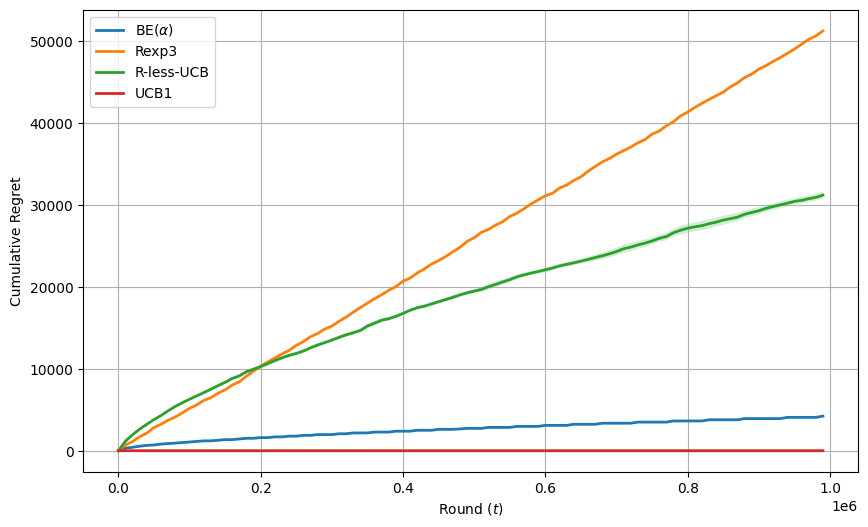

In [12]:
with open(f'{OUT_FOLDER}/{STAT_RUN_NAME}.pkl', 'rb') as f:
    results_stat_inst = pickle.load(f)
plot_comparison('stat-comparison', results_stat_inst)